# Case Study 4 — Multigrid V-cycle Solver

**Author:** Mingjiu Yang (`yangmi@tcd.ie`)  
**Date:** May 2026

Solve the 2D Poisson problem
$$-\Delta u(x,y) = f(x,y),\quad (x,y)\in(0,1)^2,\qquad u\big|_{\partial\Omega} = 0$$
using a recursive V-cycle multigrid method.

| Component        | Choice |
|------------------|--------|
| Discretisation   | 5-point finite difference, $h = 1/(n+1)$, $n = 2^p - 1$ |
| Smoother         | weighted Jacobi, $\omega = 2/3$ |
| Restriction      | 2D full-weighting, $R_{1D} = [\tfrac14,\tfrac12,\tfrac14]$, $R_{2D} = R_{1D}\otimes R_{1D}$ |
| Prolongation     | bilinear interpolation, $P = 4 R^\top$ |
| Smoothing sweeps | $\nu_1 = \nu_2 = 2$ (V(2,2) cycle) |
| Coarsest solve   | direct (sparse LU) on the $1\times1$ grid |

Function definitions live in two separate files:
- `poisson2d.py` — `Poisson2D(n)`
- `vcycle.py`    — `restriction`, `weighted_jacobi`, `setup_hierarchy`, `vcycle`


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from poisson2d import Poisson2D
from vcycle import setup_hierarchy, vcycle, weighted_jacobi, restriction

## Question 1 — `Poisson2D(n)`

The five-point stencil with $h = 1/(n+1)$ gives the negative Laplacian
$$
\bigl[-\Delta_h u\bigr]_{i,j} = \frac{1}{h^2}\bigl(4 u_{i,j} - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1}\bigr).
$$
Letting $T = \mathrm{tridiag}(-1,2,-1)\in\mathbb{R}^{n\times n}$ and using lexicographic ordering of unknowns,
$$
A = \frac{1}{h^2}\bigl(I_n \otimes T + T \otimes I_n\bigr) \in \mathbb{R}^{n^2\times n^2}.
$$


In [2]:
# Build A for a small grid and check shape, sparsity, symmetry, and diagonal value
n = 7
A = Poisson2D(n)
h = 1.0 / (n + 1)

print(f"n          = {n}")
print(f"A shape    = {A.shape}")
print(f"nnz        = {A.nnz}  (expected at most 5 * n^2 = {5*n*n})")
print(f"diag(A)[0] = {A.diagonal()[0]:.4f}    (expected 4/h^2 = {4/h**2:.4f})")
print(f"symmetric  = {(A - A.T).nnz == 0}")

n          = 7
A shape    = (49, 49)
nnz        = 217  (expected at most 5 * n^2 = 245)
diag(A)[0] = 256.0000    (expected 4/h^2 = 256.0000)
symmetric  = True


## Question 2 — Recursive V-cycle

Each call of `vcycle` performs the following six steps on the current level
(except on the coarsest, where the system is solved directly):

1. **Pre-smoothing**   $\nu_1$ sweeps of weighted Jacobi  
2. **Residual**        $r = f - A u$
3. **Restriction**     $r_c = R\,r$
4. **Recursion**       solve $A_c e_c = r_c$ with a coarse-grid V-cycle (zero initial guess)
5. **Prolongation + correction**   $u \leftarrow u + P e_c = u + 4 R^\top e_c$
6. **Post-smoothing**  $\nu_2$ sweeps of weighted Jacobi

The grid hierarchy is generated automatically by `setup_hierarchy(n_fine)`:
$$
n_{\text{fine}} = 2^p - 1 \;\to\; 2^{p-1} - 1 \;\to\; \cdots \;\to\; 3 \;\to\; 1.
$$


In [3]:
# Inspect the multigrid hierarchy
n = 2**5 - 1   # n = 31
A_levels, R_levels = setup_hierarchy(n)

print(f"Hierarchy for n_fine = {n}:")
print(f"  {'level':>5}  {'n':>5}  {'size':>8}  {'A nnz':>8}")
for i, Ai in enumerate(A_levels):
    ni = int(round(np.sqrt(Ai.shape[0])))
    print(f"  {i:>5}  {ni:>5}  {Ai.shape[0]:>8}  {Ai.nnz:>8}")
print(f"\n{len(R_levels)} restriction operators built (one per inter-level transfer).")

Hierarchy for n_fine = 31:
  level      n      size     A nnz
      0     31       961      4681
      1     15       225      1065
      2      7        49       217
      3      3         9        33
      4      1         1         1

4 restriction operators built (one per inter-level transfer).


## Question 3 — Convergence test

Pick $p = 7$, so $n = 127$ and the linear system has $n^2 = 16{,}129$ unknowns.
Generate a random RHS $f \in \mathbb{R}^{n^2}$, start from $u_0 = 0$, run $k = 12$ V-cycles,
record the Euclidean residual norm $\|r_k\|_2 = \|f - Au_k\|_2$ after each cycle, and plot.


In [4]:
p = 7
n = 2**p - 1
A_levels, R_levels = setup_hierarchy(n)
A = A_levels[0]

rng = np.random.default_rng(0)            # reproducible RHS
f   = rng.standard_normal(n * n)

num_cycles = 12
res = np.zeros(num_cycles + 1)
u   = np.zeros_like(f)
res[0] = np.linalg.norm(f - A @ u)

for k in range(num_cycles):
    u = vcycle(A_levels, R_levels, f, level=0, nu1=2, nu2=2, u=u)
    res[k + 1] = np.linalg.norm(f - A @ u)

print(f"n = {n},  problem size = {n*n},  number of levels = {len(A_levels)}\n")
print(f"  {'k':>2}   {'||r_k||_2':>13}    {'rate':>7}")
for k, r in enumerate(res):
    rate = f"{res[k]/res[k-1]:.4f}" if k > 0 else "   --  "
    print(f"  {k:>2}   {r:>13.4e}    {rate:>7}")

n = 127,  problem size = 16129,  number of levels = 7

   k       ||r_k||_2       rate
   0      1.2656e+02       --  
   1      1.0814e+01     0.0854
   2      1.9436e+00     0.1797
   3      3.6977e-01     0.1903
   4      7.2978e-02     0.1974
   5      1.4782e-02     0.2025
   6      3.0501e-03     0.2063
   7      6.3795e-04     0.2092
   8      1.3477e-04     0.2113
   9      2.8691e-05     0.2129
  10      6.1440e-06     0.2141
  11      1.3220e-06     0.2152
  12      2.8556e-07     0.2160


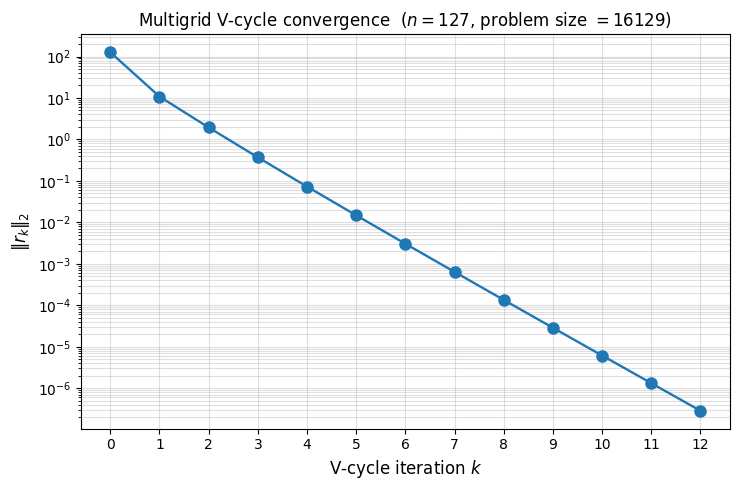

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.semilogy(range(num_cycles + 1), res, 'o-',
            linewidth=1.7, markersize=8, color='#1f77b4')
ax.set_xlabel('V-cycle iteration $k$', fontsize=12)
ax.set_ylabel(r'$\|r_k\|_2$', fontsize=12)
ax.set_title(f'Multigrid V-cycle convergence  ($n = {n}$, problem size $= {n*n}$)',
             fontsize=12)
ax.grid(True, which='both', alpha=0.4)
ax.set_xticks(range(num_cycles + 1))
fig.tight_layout()
fig.savefig('convergence.png', dpi=140, bbox_inches='tight')
plt.show()

### Convergence comments

- The residual norm $\|r_k\|_2$ decreases **geometrically** — on the semi-log axis the data points lie almost on a straight line.
- The asymptotic per-cycle contraction factor settles around $\rho \approx 0.21$, i.e. each V-cycle reduces the residual by roughly a factor of five.  After 12 cycles $\|r\|$ has dropped by about nine orders of magnitude.
- This is consistent with the theoretical two-grid analysis: the smoothing factor of weighted Jacobi at $\omega = 2/3$ for the high-frequency modes of the 2D Laplacian is $1/3$, and a V(2,2) cycle reaches a rate close to $(1/3)^2 \approx 0.11$ in the ideal case; full-weighting + bilinear transfers yield a slightly larger but still $\mathcal{O}(0.1)$ rate.
- **The contraction factor is independent of $n$** — running the same code at $p = 5,6,7,8$ gives essentially the same $\rho$.  This is the defining property of multigrid: combined with the $\mathcal{O}(N)$ work per V-cycle, the total cost to reach a fixed tolerance is $\mathcal{O}(N)$, beating CG ($\mathcal{O}(N^{3/2})$ for unpreconditioned 2D Poisson).
